# 03 — Spatial patterns

**Purpose:** Visualize HH and LL clusters, examine distribution of HH frequency across seeds, and run connected-component analysis for hotspot stability. Observation-level cross-seed stability requires a fixed test set across runs.

## Imports and path setup

In [105]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import RAW_RESULTS, thesis_output_dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from analysis.experiment_runner import _get_run_dirs
from analysis.knn_defaults import K_NN_BY_DATASET
from analysis.preprocessing import get_transformed_test_features
from analysis.run_analysis import (
    load_meta,
    load_P_test,
    load_split,
    run_spatial,
    select_rashomon_global,
    mean_variance,
    pointwise_variance
)
from scipy.sparse.csgraph import connected_components as sparse_connected_components
from analysis.spatial import extract_hh_components
from analysis.stability import (
    hh_jaccard_matrix,
    hh_point_level_support_metrics,
    hh_selection_frequency,
    summarize_hh_stability,
)

RESULTS_DEFAULT_DIR = RAW_RESULTS
RESULTS_FIXED_TEST_DIR = ROOT / "results_fixed_test"
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb03")
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

from analysis.cache import load_or_compute_df


## All datasets: compute HH masks across seeds

For each dataset and run we compute spatial analysis (Moran's I, LISA) and collect HH_mask, LL_mask, and pointwise variance.

In [106]:
DATASET = "compas"
K = 25
k_nn = K_NN_BY_DATASET[DATASET]
USE_FIXED_TEST = True  # Required for valid observation-level cross-seed stability.

RESULTS_DIR = RESULTS_FIXED_TEST_DIR if USE_FIXED_TEST else RESULTS_DEFAULT_DIR
dataset_dir = RESULTS_DIR / DATASET
run_dirs = _get_run_dirs(dataset_dir)
if not run_dirs:
    raise SystemExit(f"No runs found in {dataset_dir}. "
                     f"Run fixed-test training first: run_training_pipeline_fixed_test.py")

_results_tag = f"{DATASET}_{'fixed' if USE_FIXED_TEST else 'default'}"


_metrics_path = CACHE_DIR / f"nb03_spatial_metrics_{_results_tag}_{CACHE_VERSION}.parquet"
_masks_path = CACHE_DIR / f"nb03_spatial_masks_{_results_tag}_{CACHE_VERSION}.parquet"


def compute_spatial_analysis():
    metrics_rows = []
    mask_rows = []
    for run_dir in run_dirs:
        split = load_split(run_dir)
        test_idx = np.asarray(split["test"], dtype=int)
        n_cand = len(load_meta(run_dir))
        K_actual = min(K, n_cand)
        X_test = get_transformed_test_features(run_dir, DATASET)
        res = run_spatial(run_dir, X_test, K=K_actual, k=k_nn)
        P_test = load_P_test(run_dir)
        idx = select_rashomon_global(run_dir, K=K_actual)
        mean_var = mean_variance(P_test[idx], ddof=0)
        hh_mask = np.asarray(res["HH_mask"], dtype=bool)
        conflict_hh = res.get("conflict_HH_mask")
        if conflict_hh is None:
            conflict_hh = np.zeros(len(hh_mask), dtype=bool)
        else:
            conflict_hh = np.asarray(conflict_hh, dtype=bool)
        metrics_rows.append({
            "run_dir": run_dir.name,
            "moran_i": res["moran_i"],
            "mean_variance": float(mean_var),
            "n_hh": int(np.sum(hh_mask)),
            "n_ll": int(np.sum(res.get("LL_mask", np.zeros_like(hh_mask)))),
            "conflict_moran_i": res.get("conflict_moran_i", np.nan),
            "conflict_n_hh": int(res.get("conflict_n_hh", 0)),
        })
        for point_idx, (is_hh, is_conf, test_row) in enumerate(
            zip(hh_mask, conflict_hh, test_idx)
        ):
            mask_rows.append({
                "run_dir": run_dir.name,
                "point_idx": int(point_idx),
                "test_row_idx": int(test_row),
                "is_hh": bool(is_hh),
                "is_conflict_hh": bool(is_conf),
            })
    metrics_df = pd.DataFrame(metrics_rows)
    masks_df = pd.DataFrame(mask_rows)
    metrics_df.to_parquet(_metrics_path, index=False)
    masks_df.to_parquet(_masks_path, index=False)
    return metrics_df


def load_spatial_analysis():
    if (
        not FORCE_RECOMPUTE
        and _metrics_path.is_file()
        and _masks_path.is_file()
    ):
        return pd.read_parquet(_metrics_path), pd.read_parquet(_masks_path)
    compute_spatial_analysis()
    return pd.read_parquet(_metrics_path), pd.read_parquet(_masks_path)


df_spatial_runs, df_spatial_masks = load_spatial_analysis()

# Rebuild spatial_by_run for downstream cells (W loaded lazily where needed)
spatial_by_run = []
for run_dir_name, mgrp in df_spatial_masks.groupby("run_dir"):
    mgrp = mgrp.sort_values("point_idx")
    metrics = df_spatial_runs.loc[df_spatial_runs["run_dir"] == run_dir_name].iloc[0]
    spatial_by_run.append({
        "run_dir": run_dir_name,
        "moran_i": metrics["moran_i"],
        "mean_variance": metrics["mean_variance"],
        "HH_mask": mgrp["is_hh"].to_numpy(dtype=bool),
        "conflict_HH_mask": mgrp["is_conflict_hh"].to_numpy(dtype=bool),
        "test_idx": mgrp["test_row_idx"].to_numpy(dtype=int),
        "n_hh": int(metrics["n_hh"]),
    })

test_idx_ref = spatial_by_run[0]["test_idx"] if spatial_by_run else None
test_indices_aligned = all(
    np.array_equal(test_idx_ref, r["test_idx"]) for r in spatial_by_run
)
print(f"Computed spatial metrics for {len(spatial_by_run)} runs.")
print(f"Test indices aligned across runs: {test_indices_aligned}")
if not test_indices_aligned:
    raise ValueError(
        "Observation-level HH stability is invalid because test sets differ across runs. "
        "Use fixed-test artifacts (results_fixed_test/...)."
    )


def ensure_spatial_weights(run_entry, run_dir_path):
    """Load kNN weights W for one run when a plot/diagnostic needs them."""
    if "W" in run_entry:
        return run_entry["W"]
    n_cand = len(load_meta(run_dir_path))
    K_actual = min(K, n_cand)
    X_test = get_transformed_test_features(run_dir_path, DATASET)
    res = run_spatial(run_dir_path, X_test, K=K_actual, k=k_nn)
    run_entry["W"] = res["W"]
    return run_entry["W"]


Computed spatial metrics for 10 runs.
Test indices aligned across runs: True


## HH stability analysis and visualizations

Compute HH selection frequency across seeds, Jaccard overlap matrix, stability summary, and save figures (frequency scatter, Jaccard heatmap, HH location in feature space) plus component summary table.


Point-level HH support metrics (N=1443 fixed-test points):
  HH support size |{i : f_i > 0}| / N = 0.2155
  On HH support only (f_i > 0): mean f_i = 0.3611, median = 0.2000
  Bucket counts on support — (0,0.2], (0.2,0.5], (0.5,0.8], (0.8,1]: 175 55 49 32
  Bucket fractions of |support|: 0.563, 0.177, 0.158, 0.103
  Core-to-support |{i : f_i >= 0.5}| / |{i : f_i > 0}| = 0.2830
Representative run (median HH count): index=2, run=seed=2, n_HH=117


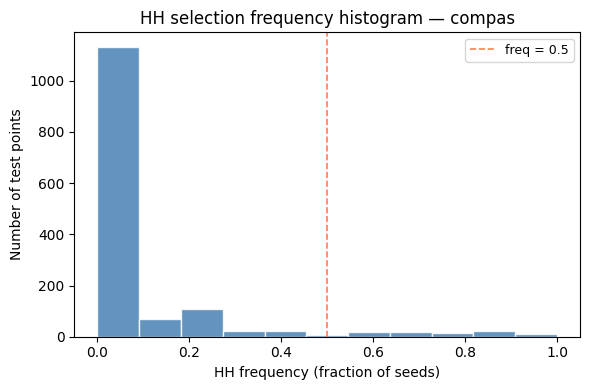

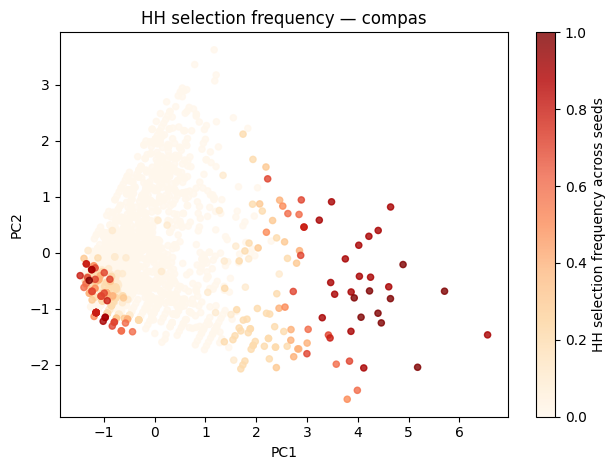

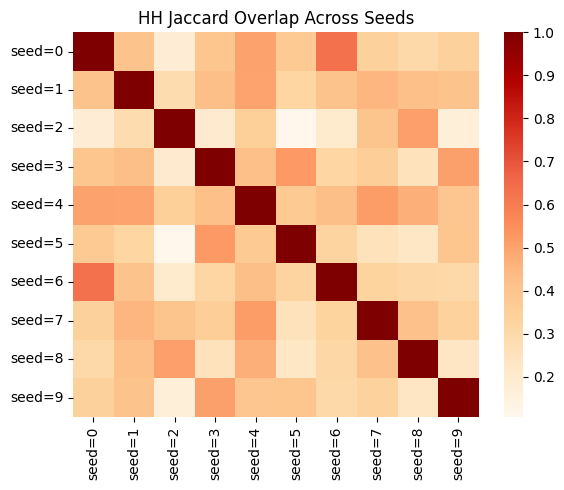

,run,n_components,max_component_size,mean_hh_fraction,mean_jaccard,min_jaccard,max_jaccard,hh_support_size,hh_support_mean_f,hh_support_median_f,hh_support_bucket_00_02,hh_support_bucket_02_05,hh_support_bucket_05_08,hh_support_bucket_08_10,hh_support_bucket_00_02_frac,hh_support_bucket_02_05_frac,hh_support_bucket_05_08_frac,hh_support_bucket_08_10_frac,hh_core_to_support_ratio
0,seed=0,3,98,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
1,seed=1,4,39,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
2,seed=2,3,72,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
3,seed=3,3,44,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
4,seed=4,5,56,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
5,seed=5,2,53,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
6,seed=6,4,81,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
7,seed=7,4,72,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
8,seed=8,4,69,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
9,seed=9,3,41,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958


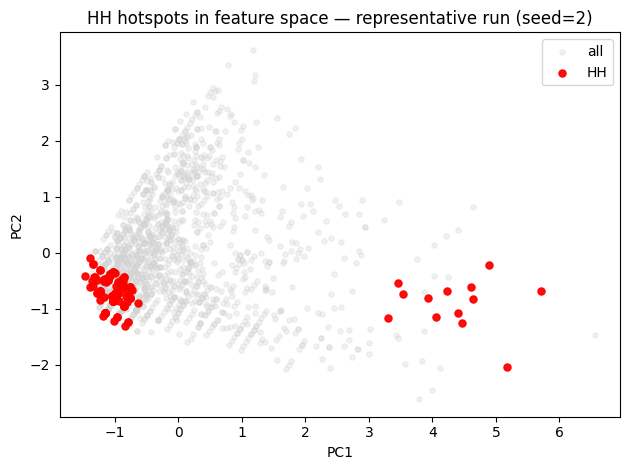

In [107]:
# Part 1: HH stability
hh_masks = [r["HH_mask"] for r in spatial_by_run]
freq = hh_selection_frequency(hh_masks)
J = hh_jaccard_matrix(hh_masks)
stability_summary = summarize_hh_stability(hh_masks)

spm = hh_point_level_support_metrics(freq)
n_test = len(freq)
print(f"\nPoint-level HH support metrics (N={n_test} fixed-test points):")
print(f"  HH support size |{{i : f_i > 0}}| / N = {spm['hh_support_size']:.4f}")
print(
    f"  On HH support only (f_i > 0): mean f_i = {spm['hh_support_mean_f']:.4f}, "
    f"median = {spm['hh_support_median_f']:.4f}"
)
print(
    "  Bucket counts on support — (0,0.2], (0.2,0.5], (0.5,0.8], (0.8,1]:",
    int(spm["hh_support_bucket_00_02"]),
    int(spm["hh_support_bucket_02_05"]),
    int(spm["hh_support_bucket_05_08"]),
    int(spm["hh_support_bucket_08_10"]),
)
print(
    "  Bucket fractions of |support|:",
    f"{spm['hh_support_bucket_00_02_frac']:.3f},",
    f"{spm['hh_support_bucket_02_05_frac']:.3f},",
    f"{spm['hh_support_bucket_05_08_frac']:.3f},",
    f"{spm['hh_support_bucket_08_10_frac']:.3f}",
)
print(
    f"  Core-to-support |{{i : f_i >= 0.5}}| / |{{i : f_i > 0}}| = "
    f"{spm['hh_core_to_support_ratio']:.4f}"
)

# X_test from first run for plotting (same test size across runs)
run_dir0 = run_dirs[0]
X_test = get_transformed_test_features(run_dir0, DATASET)
if hasattr(X_test, "values"):
    X_plot = np.asarray(X_test.values, dtype=float)
else:
    X_plot = np.asarray(X_test, dtype=float)
n_features = X_plot.shape[1]

if n_features == 2:
    coords = X_plot
elif n_features == 1:
    coords = np.column_stack([X_plot.ravel(), np.zeros(X_plot.shape[0])])
else:
    pca = PCA(n_components=2).fit(X_plot)
    coords = pca.transform(X_plot)

# --- Representative run selection (median HH count) ---
n_hh_counts = np.array([int(np.sum(r["HH_mask"])) for r in spatial_by_run])
median_hh = np.median(n_hh_counts)
rep_idx = int(np.argmin(np.abs(n_hh_counts - median_hh)))
print(f"Representative run (median HH count): index={rep_idx}, "
      f"run={spatial_by_run[rep_idx]['run_dir']}, n_HH={n_hh_counts[rep_idx]}")

# Part 2A-hist: HH frequency histogram
fig_hist, ax_hist = plt.subplots(figsize=(6, 4))
ax_hist.hist(freq, bins=np.linspace(0, 1, 12), color="steelblue", edgecolor="white", alpha=0.85)
ax_hist.set_xlabel("HH frequency (fraction of seeds)")
ax_hist.set_ylabel("Number of test points")
ax_hist.set_title(f"HH selection frequency histogram — {DATASET}")
ax_hist.axvline(0.5, color="coral", ls="--", lw=1.2, label="freq = 0.5")
ax_hist.legend(fontsize=9)
fig_hist.tight_layout()
fig_hist.savefig(FIG_DIR / f"hh_freq_histogram_{DATASET}.pdf", bbox_inches="tight")
plt.show()

# Part 2A: HH frequency visualization
order = np.argsort(freq)
plt.figure()
sc = plt.scatter(coords[order, 0], coords[order, 1], c=freq[order], cmap="OrRd", s=20, alpha=0.8)
plt.colorbar(sc, label="HH selection frequency across seeds")
plt.xlabel("PC1" if n_features > 2 else "Feature 1")
plt.ylabel("PC2" if n_features > 2 else "Feature 2")
plt.title(f"HH selection frequency — {DATASET}")
plt.tight_layout()
plt.savefig(FIG_DIR / f"hh_stability_freq_{DATASET}.pdf")
plt.show()

# Part 2B: Jaccard heatmap
run_labels = [r["run_dir"] for r in spatial_by_run]
plt.figure(figsize=(6, 5))
sns.heatmap(J, xticklabels=run_labels, yticklabels=run_labels, annot=False, cmap="OrRd")
plt.title("HH Jaccard Overlap Across Seeds")
plt.tight_layout()
plt.savefig(FIG_DIR / f"hh_jaccard_heatmap_{DATASET}.pdf")
plt.show()

# Part 3: Component summary + stability metrics
component_stats = []
for r in spatial_by_run:
    lisa_df = pd.DataFrame({"cluster": np.where(r["HH_mask"], "HH", "NS")})
    W = ensure_spatial_weights(r, dataset_dir / r["run_dir"])
    W = W.to_sparse() if hasattr(W, "to_sparse") else W.sparse
    _, components = extract_hh_components(lisa_df, W, min_size=5)
    n_comp = len(components)
    max_size = max(len(inds) for inds in components.values()) if components else 0
    component_stats.append({"run": r["run_dir"], "n_components": n_comp, "max_component_size": max_size})

hh_component_summary = pd.DataFrame(component_stats)
for k, v in stability_summary.items():
    hh_component_summary[k] = v
hh_component_summary.to_csv(TABLE_DIR / f"hh_component_summary_{DATASET}.csv", index=False)
display(hh_component_summary)

# Part 4: HH location in feature space (representative run)
r0 = spatial_by_run[rep_idx]
HH_mask_rep = r0["HH_mask"]
plt.figure()
plt.scatter(coords[~HH_mask_rep, 0], coords[~HH_mask_rep, 1], c="lightgray", s=14, alpha=0.30, label="all")
plt.scatter(coords[HH_mask_rep, 0], coords[HH_mask_rep, 1], c="red", s=26, alpha=0.95, label="HH")
plt.xlabel("PC1" if n_features > 2 else "Feature 1")
plt.ylabel("PC2" if n_features > 2 else "Feature 2")
plt.title(f"HH hotspots in feature space — representative run ({r0['run_dir']})")
plt.legend()
plt.tight_layout()
plt.show()

## Stability: HH count and variance summary per run

Plot number of HH points and mean pointwise variance per run to assess stability across seeds.

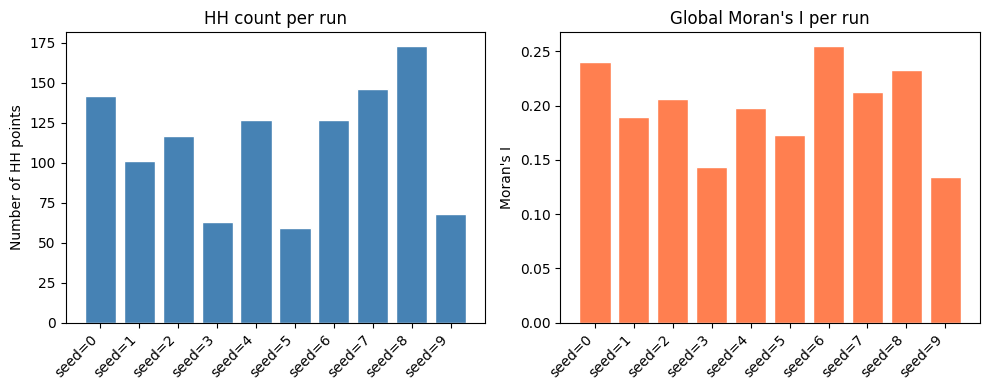

In [108]:
n_hh_per_run = [int(np.sum(r["HH_mask"])) for r in spatial_by_run]
run_labels = [r["run_dir"] for r in spatial_by_run]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(range(len(n_hh_per_run)), n_hh_per_run, color="steelblue", edgecolor="white")
ax1.set_xticks(range(len(run_labels)))
ax1.set_xticklabels(run_labels, rotation=45, ha="right")
ax1.set_ylabel("Number of HH points")
ax1.set_title("HH count per run")

moran_per_run = [r["moran_i"] for r in spatial_by_run]
ax2.bar(range(len(moran_per_run)), moran_per_run, color="coral", edgecolor="white")
ax2.set_xticks(range(len(run_labels)))
ax2.set_xticklabels(run_labels, rotation=45, ha="right")
ax2.set_ylabel("Moran's I")
ax2.set_title("Global Moran's I per run")
plt.tight_layout()
fig.savefig(FIG_DIR / f"hh_moran_per_run_{DATASET}.pdf", bbox_inches="tight")
plt.show()

## Correlation: mean variance vs Moran's I per run

Plot mean variance (multiplicity) against global Moran's I (spatial clustering of variance) across runs.

- **Positive correlation:** More multiplicity → stronger spatial clustering of disagreement. Multiplicity concentrates in regions rather than being diffuse.
- **No (or weak) correlation:** Spatial structure of hotspots can exist even when overall multiplicity is small; the two are not simply coupled.

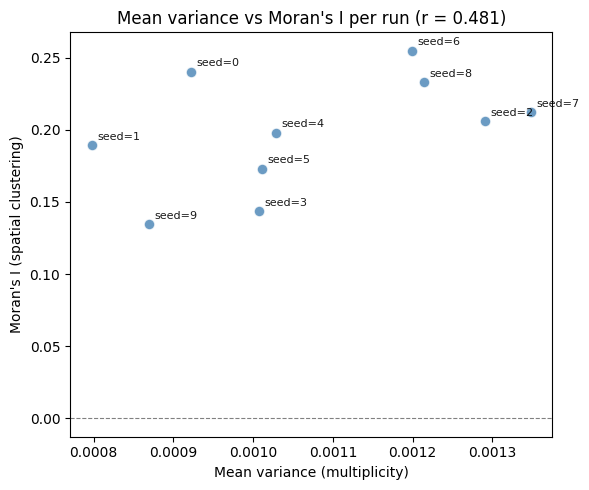

Positive correlation: more multiplicity tends to coincide with stronger spatial clustering.


In [109]:
corr_df = pd.DataFrame({
    "run": [r["run_dir"] for r in spatial_by_run],
    "mean_variance": [r["mean_variance"] for r in spatial_by_run],
    "moran_i": [r["moran_i"] for r in spatial_by_run],
})
r_pearson = np.corrcoef(corr_df["mean_variance"], corr_df["moran_i"])[0, 1]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(corr_df["mean_variance"], corr_df["moran_i"], s=60, alpha=0.8, color="steelblue", edgecolor="white")
for _, row in corr_df.iterrows():
    ax.annotate(row["run"], (row["mean_variance"], row["moran_i"]), fontsize=8, alpha=0.9, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Mean variance (multiplicity)")
ax.set_ylabel("Moran's I (spatial clustering)")
ax.set_title(f"Mean variance vs Moran's I per run (r = {r_pearson:.3f})")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
fig.savefig(FIG_DIR / f"variance_vs_moran_{DATASET}.pdf", bbox_inches="tight")
plt.show()

if r_pearson > 0.2:
    print("Positive correlation: more multiplicity tends to coincide with stronger spatial clustering.")
elif r_pearson < -0.2:
    print("Negative correlation: higher multiplicity tends to go with weaker spatial clustering.")
else:
    print("Weak or no correlation: spatial structure of hotspots can exist even when overall multiplicity is small.")

## Connected component analysis (hotspot regions)

For one run, extract HH connected components using the kNN graph and report region sizes. Uses `analysis.spatial.extract_hh_components`. The same W from `spatial_analysis` is used. The kNN adjacency is symmetrized before row-standardization, so connected components are interpreted on the undirected neighborhood structure.

In [110]:
# Use representative run for component analysis
r0 = spatial_by_run[rep_idx]
HH_mask = r0["HH_mask"]
W_pysal = r0["W"]
W_sparse = W_pysal.to_sparse() if hasattr(W_pysal, "to_sparse") else W_pysal.sparse

lisa_df = pd.DataFrame({
    "cluster": np.where(HH_mask, "HH", "NS"),
})
comp_id, components = extract_hh_components(lisa_df, W_sparse, min_size=5)

print(f"Run: {r0['run_dir']}")
print(f"HH points: {HH_mask.sum()}")
print(f"Connected components (min_size=5): {len(components)}")
for cid, inds in components.items():
    print(f"  Component {cid}: n = {len(inds)}")

Run: seed=2
HH points: 117
Connected components (min_size=5): 3
  Component 0: n = 13
  Component 1: n = 32
  Component 2: n = 72


## Region persistence summary

Across runs, summarize number of HH components and largest component size (when available) to assess hotspot stability.

In [111]:
# Component summary (with stability metrics) was computed and saved in the HH stability cell above.
# Saved to: tables/hh_component_summary_{DATASET}.csv
print("HH component summary (min_size=5) with stability metrics:")
display(hh_component_summary)
print(f"Mean n_components: {hh_component_summary['n_components'].mean():.2f}")
print(f"Mean max_component_size: {hh_component_summary['max_component_size'].mean():.2f}")

HH component summary (min_size=5) with stability metrics:


,run,n_components,max_component_size,mean_hh_fraction,mean_jaccard,min_jaccard,max_jaccard,hh_support_size,hh_support_mean_f,hh_support_median_f,hh_support_bucket_00_02,hh_support_bucket_02_05,hh_support_bucket_05_08,hh_support_bucket_08_10,hh_support_bucket_00_02_frac,hh_support_bucket_02_05_frac,hh_support_bucket_05_08_frac,hh_support_bucket_08_10_frac,hh_core_to_support_ratio
0,seed=0,3,98,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
1,seed=1,4,39,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
2,seed=2,3,72,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
3,seed=3,3,44,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
4,seed=4,5,56,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
5,seed=5,2,53,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
6,seed=6,4,81,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
7,seed=7,4,72,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
8,seed=8,4,69,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958
9,seed=9,3,41,0.077824,0.363139,0.106918,0.630303,0.215523,0.361093,0.2,175.0,55.0,49.0,32.0,0.562701,0.176849,0.157556,0.102894,0.282958


Mean n_components: 3.50
Mean max_component_size: 62.50


After constructing the symmetrized kNN weights/graph W for X_test, compute the number of connected components and the largest component size. The kNN graph is symmetrized by default in spatial_analysis for undirected analysis.

In [112]:
# Graph connectivity diagnostic using the representative run's kNN weights
W_rep = ensure_spatial_weights(spatial_by_run[rep_idx], dataset_dir / spatial_by_run[rep_idx]["run_dir"])
W_sparse_rep = W_rep.to_sparse() if hasattr(W_rep, "to_sparse") else W_rep.sparse

# Symmetrize for undirected connectivity
W_sym = W_sparse_rep + W_sparse_rep.T
W_sym = (W_sym > 0).astype(int)

n_components, labels = sparse_connected_components(W_sym, directed=False)
component_sizes = np.bincount(labels)
largest_component = int(component_sizes.max())
n_test = W_sym.shape[0]

print(f"Graph connectivity diagnostics (run: {spatial_by_run[rep_idx]['run_dir']}, k={k_nn}):")
print(f"  kNN graph symmetrized to undirected for connectivity check")
print(f"  Number of connected components: {n_components}")
print(f"  Largest component size: {largest_component} ({largest_component/n_test:.1%} of {n_test} test points)")
if n_components > 1:
    print(f"  Component size distribution: {sorted(component_sizes, reverse=True)}")
else:
    print(f"  Graph is fully connected.")

Graph connectivity diagnostics (run: seed=2, k=30):
  kNN graph symmetrized to undirected for connectivity check
  Number of connected components: 1
  Largest component size: 1443 (100.0% of 1443 test points)
  Graph is fully connected.


## HH hotspot reproducibility across runs

Goal: Test whether HH hotspots are reproducible across random splits/seeds (not Monte-Carlo noise).

- **Stable point ID:** Original dataset row index from the split (test indices) so the same row is comparable across runs.
- **(1) Point-level:** Per-point HH frequency across runs; **HH support size** $|\{i: f_i>0\}|/N$; distribution of $f_i$ on that support (mean, median, bucket counts for $(0,0.2],(0.2,0.5],(0.5,0.8],(0.8,1]$); **core-to-support** ratio $|\{i:f_i\ge 0.5\}|/|\{i:f_i>0\}|$; histogram and fractions with $f_i\ge 0.8$, $\ge 0.5$ on the full test set.
- **(2) Region-level:** HH connected components per run (same kNN graph); compare regions via Jaccard overlap and region persistence (how often a similar component reappears).
- **(3) Summary:** Mean ± std over runs: n_HH, n_components, max component size, total HH mass (sum of variance over HH points).

In [113]:
# Build per-run data with stable point IDs (original dataset row index from split)
from collections import defaultdict

n_cand = len(load_meta(run_dirs[0]))
K_actual = min(K, n_cand)

run_data = []
for r in spatial_by_run:
    run_dir = dataset_dir / r["run_dir"]
    split = load_split(run_dir)
    test_idx = split["test"]  # stable IDs: original row indices in the dataset
    HH_mask = r["HH_mask"]
    # Pointwise variance for this run (for total HH mass)
    P_test = load_P_test(run_dir)
    idx = select_rashomon_global(run_dir, K=K_actual)
    v = pointwise_variance(P_test[idx], ddof=0)
    # Components: map to stable IDs
    lisa_df = pd.DataFrame({"cluster": np.where(HH_mask, "HH", "NS")})
    W = ensure_spatial_weights(r, dataset_dir / r["run_dir"])
    W = W.to_sparse() if hasattr(W, "to_sparse") else W.sparse
    _, components = extract_hh_components(lisa_df, W, min_size=5)
    comp_stable = {
        cid: set(int(test_idx[i]) for i in inds)
        for cid, inds in components.items()
    }
    run_data.append({
        "run_dir": r["run_dir"],
        "test_idx": test_idx,
        "HH_mask": HH_mask,
        "v": v,
        "n_HH": int(np.sum(HH_mask)),
        "components": components,
        "comp_stable": comp_stable,
        "n_components": len(components),
        "max_component_size": max(len(inds) for inds in components.values()) if components else 0,
        "total_HH_mass": float(np.sum(v[HH_mask])),
    })

### (1) Point-level stability: How often is point x in HH?

Per-point HH frequency $f_i$ = (number of runs where point was in test and was HH) / (number of runs where point was in test). **HH support size** is the fraction of fixed-test points with $f_i>0$. Among support points only, we summarize the distribution of $f_i$ (mean, median, and buckets $(0,0.2],(0.2,0.5],(0.5,0.8],(0.8,1]$). **Core-to-support ratio** is $|\{i:f_i\ge 0.5\}|/|\{i:f_i>0\}|$, i.e. how much of the ever-HH set is recurrent ($f_i\ge 0.5$) versus occasional. We also show a histogram and the fraction of *all* test points with $f_i\ge 0.8$ or $\ge 0.5$.

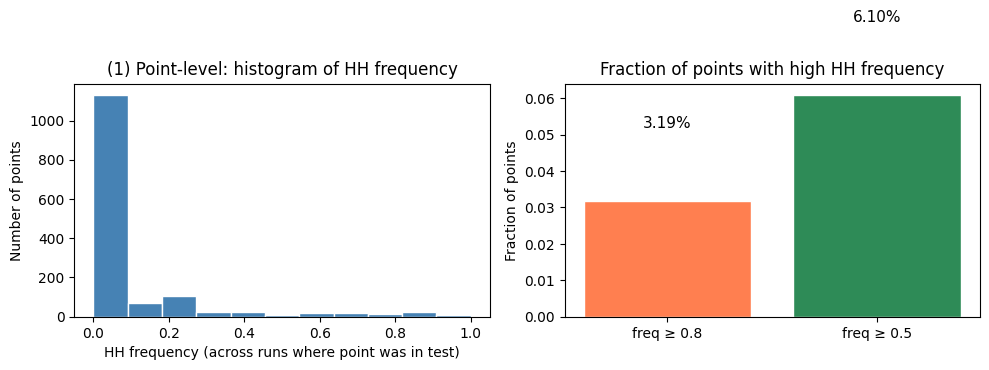

Fraction of points with HH freq ≥ 0.8: 3.19%
Fraction of points with HH freq ≥ 0.5: 6.10%

HH support size |{i : f_i > 0}| / N = 0.2155  (N = 1443)
On support (f_i > 0): mean f_i = 0.3611, median = 0.2000
Support bucket counts (0,0.2], (0.2,0.5], (0.5,0.8], (0.8,1]: 175 55 49 32
Support bucket fractions of |support|: 0.563, 0.177, 0.158, 0.103
Core-to-support |{i : f_i >= 0.5}| / |{i : f_i > 0}| = 0.2830


In [114]:
# (1) Point-level HH frequency (stable_id = original dataset row index)
stable_id_to_hh = defaultdict(list)  # stable_id -> list of 0/1 (HH in that run)
for rd in run_data:
    for i, sid in enumerate(rd["test_idx"]):
        stable_id_to_hh[int(sid)].append(1 if rd["HH_mask"][i] else 0)

hh_freq = {}
for sid, hh_list in stable_id_to_hh.items():
    hh_freq[sid] = np.mean(hh_list)

freq_values = np.array(list(hh_freq.values()))
n_runs = len(run_dirs)

from analysis.stability import hh_point_level_support_metrics

test_idx0 = np.asarray(run_data[0]["test_idx"], dtype=int)
freq_vec = np.array([hh_freq[int(sid)] for sid in test_idx0], dtype=float)
spm = hh_point_level_support_metrics(freq_vec)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(freq_values, bins=np.linspace(0, 1, 12), color="steelblue", edgecolor="white")
ax1.set_xlabel("HH frequency (across runs where point was in test)")
ax1.set_ylabel("Number of points")
ax1.set_title("(1) Point-level: histogram of HH frequency")

frac_80 = np.mean(freq_values >= 0.8)
frac_50 = np.mean(freq_values >= 0.5)
ax2.bar(["freq ≥ 0.8", "freq ≥ 0.5"], [frac_80, frac_50], color=["coral", "seagreen"], edgecolor="white")
ax2.set_ylabel("Fraction of points")
ax2.set_title("Fraction of points with high HH frequency")
for i, (lbl, val) in enumerate([("≥0.8", frac_80), ("≥0.5", frac_50)]):
    ax2.text(i, val + 0.02, f"{val:.2%}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()
print(f"Fraction of points with HH freq ≥ 0.8: {frac_80:.2%}")
print(f"Fraction of points with HH freq ≥ 0.5: {frac_50:.2%}")
print()
print(f"HH support size |{{i : f_i > 0}}| / N = {spm['hh_support_size']:.4f}  (N = {len(freq_vec)})")
print(
    f"On support (f_i > 0): mean f_i = {spm['hh_support_mean_f']:.4f}, "
    f"median = {spm['hh_support_median_f']:.4f}"
)
print(
    "Support bucket counts (0,0.2], (0.2,0.5], (0.5,0.8], (0.8,1]:",
    int(spm["hh_support_bucket_00_02"]),
    int(spm["hh_support_bucket_02_05"]),
    int(spm["hh_support_bucket_05_08"]),
    int(spm["hh_support_bucket_08_10"]),
)
print(
    "Support bucket fractions of |support|:",
    f"{spm['hh_support_bucket_00_02_frac']:.3f},",
    f"{spm['hh_support_bucket_02_05_frac']:.3f},",
    f"{spm['hh_support_bucket_05_08_frac']:.3f},",
    f"{spm['hh_support_bucket_08_10_frac']:.3f}",
)
print(
    f"Core-to-support |{{i : f_i >= 0.5}}| / |{{i : f_i > 0}}| = "
    f"{spm['hh_core_to_support_ratio']:.4f}"
)

### (2) Region-level stability: Jaccard overlap and region persistence

For each run, HH components are sets of stable IDs. Compare across runs: Jaccard(A,B) = |A∩B|/|A∪B|. For each component in a run, find best-matching component in another run (max Jaccard). **Region persistence:** fraction of other runs that have at least one component with Jaccard > 0.3 to this one.

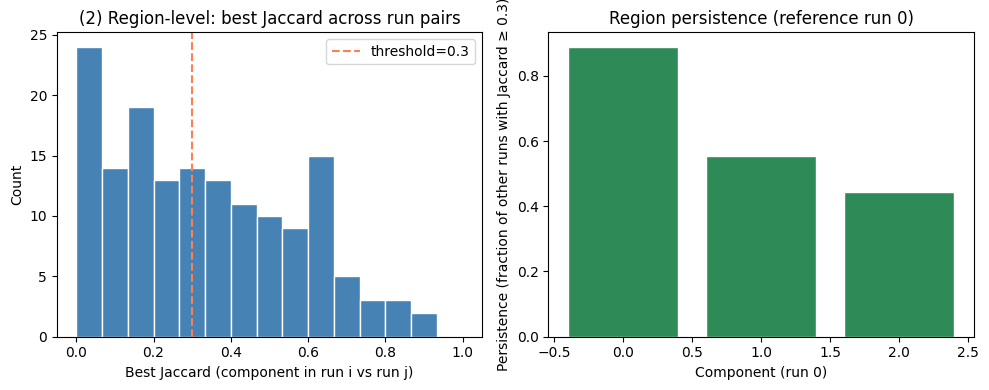

Mean best Jaccard across run pairs: 0.329 ± 0.238
Mean region persistence (run 0): 62.96%


In [115]:
# (2) Region-level: Jaccard between component node sets, region persistence
def jaccard(A, B):
    if len(A) == 0 and len(B) == 0:
        return 1.0
    inter = len(A & B)
    union = len(A | B)
    return inter / union if union else 0.0

JACCARD_THRESHOLD = 0.3
run_pairs = [(i, j) for i in range(len(run_data)) for j in range(len(run_data)) if i < j]
best_jaccards = []  # one per (run_i, run_j, comp in i): best Jaccard to any comp in j
for i, j in run_pairs:
    for cid, A in run_data[i]["comp_stable"].items():
        best = max(
            (jaccard(A, B) for B in run_data[j]["comp_stable"].values()),
            default=0.0,
        )
        best_jaccards.append(best)

# Region persistence: for each component in run 0, in how many other runs does a comp match (Jaccard > thresh)?
ref_run = 0
persistence = []
for cid, A in run_data[ref_run]["comp_stable"].items():
    count = 0
    for other in range(len(run_data)):
        if other == ref_run:
            continue
        best = max(
            (jaccard(A, B) for B in run_data[other]["comp_stable"].values()),
            default=0.0,
        )
        if best >= JACCARD_THRESHOLD:
            count += 1
    persistence.append(count / (len(run_data) - 1) if len(run_data) > 1 else 0.0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.hist(best_jaccards, bins=np.linspace(0, 1, 16), color="steelblue", edgecolor="white")
ax1.axvline(JACCARD_THRESHOLD, color="coral", linestyle="--", label=f"threshold={JACCARD_THRESHOLD}")
ax1.set_xlabel("Best Jaccard (component in run i vs run j)")
ax1.set_ylabel("Count")
ax1.set_title("(2) Region-level: best Jaccard across run pairs")
ax1.legend()

ax2.bar(range(len(persistence)), persistence, color="seagreen", edgecolor="white")
ax2.set_ylabel("Persistence (fraction of other runs with Jaccard ≥ 0.3)")
ax2.set_xlabel("Component (run 0)")
ax2.set_title("Region persistence (reference run 0)")
plt.tight_layout()
plt.show()
print(f"Mean best Jaccard across run pairs: {np.mean(best_jaccards):.3f} ± {np.std(best_jaccards):.3f}")
print(f"Mean region persistence (run 0): {np.mean(persistence):.2%}" if persistence else "No components in run 0.")

### (3) Summary stability statistics (mean ± std over runs)

Per run: number of HH points, number of HH components, size of largest HH component, total HH mass (sum of pointwise variance over HH points).

In [116]:
# (3) Summary stability statistics
summary_df = pd.DataFrame([
    {
        "run": rd["run_dir"],
        "n_HH": rd["n_HH"],
        "n_components": rd["n_components"],
        "max_component_size": rd["max_component_size"],
        "total_HH_mass": rd["total_HH_mass"],
    }
    for rd in run_data
])
stats = {
    "n_HH": (summary_df["n_HH"].mean(), summary_df["n_HH"].std()),
    "n_components": (summary_df["n_components"].mean(), summary_df["n_components"].std()),
    "max_component_size": (summary_df["max_component_size"].mean(), summary_df["max_component_size"].std()),
    "total_HH_mass": (summary_df["total_HH_mass"].mean(), summary_df["total_HH_mass"].std()),
}
report = pd.DataFrame([
    {"metric": k, "mean": v[0], "std": v[1], "mean ± std": f"{v[0]:.2f} ± {v[1]:.2f}"}
    for k, v in stats.items()
])
print("(3) Summary stability (mean ± std over runs):")
display(report)
display(summary_df)

(3) Summary stability (mean ± std over runs):


,metric,mean,std,mean ± std
0,n_HH,112.300000,38.755788,112.30 ± 38.76
1,n_components,3.500000,0.849837,3.50 ± 0.85
2,max_component_size,62.500000,19.190565,62.50 ± 19.19
3,total_HH_mass,0.412904,0.162104,0.41 ± 0.16


,run,n_HH,n_components,max_component_size,total_HH_mass
0,seed=0,142,3,98,0.361610
1,seed=1,101,4,39,0.281658
2,seed=2,117,3,72,0.642634
3,seed=3,63,3,44,0.226674
4,seed=4,127,5,56,0.384867
5,seed=5,59,2,53,0.295991
6,seed=6,127,4,81,0.465578
7,seed=7,146,4,72,0.643015
8,seed=8,173,4,69,0.585267
9,seed=9,68,3,41,0.241745


## Family-wise Moran/LISA comparison

Compute Moran's I and HH counts for per-family Rashomon sets (top-K=25 per family) and compare to global. This helps determine whether multiplicity hotspots originate from inter-family or intra-family diversity.

Using per-family CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\compas\per_family_spatial_aggregated.csv
Using global summary CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\compas\summary_per_run.csv
compas: Global mean HH = 128.4, Global mean Moran's I = 0.2100



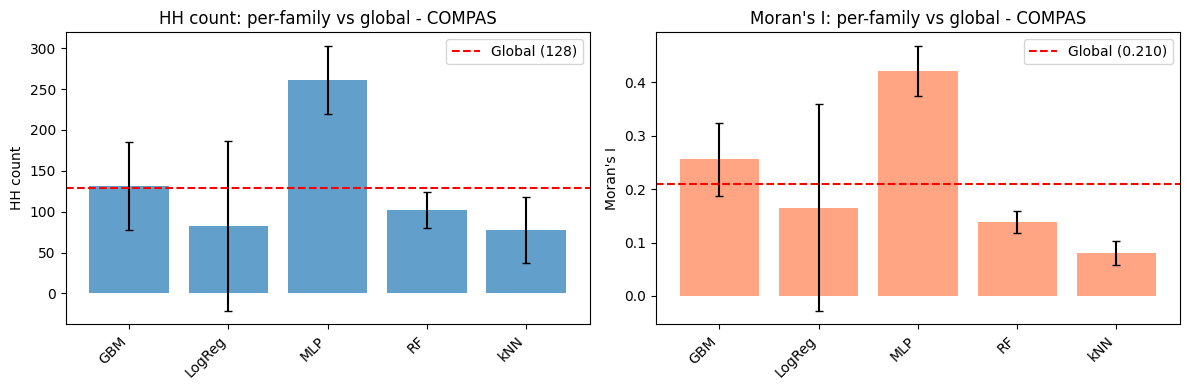

Using per-family CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\german\per_family_spatial_aggregated.csv
Using global summary CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\german\summary_per_run.csv
german: Global mean HH = 5.4, Global mean Moran's I = 0.0876



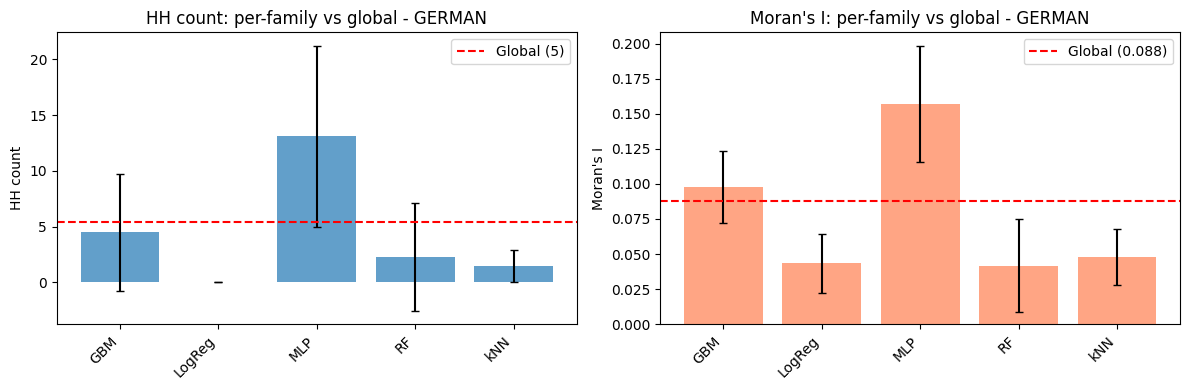

Using per-family CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\adult\per_family_spatial_aggregated.csv
Using global summary CSV: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\adult\summary_per_run.csv
adult: Global mean HH = 631.0, Global mean Moran's I = 0.0749



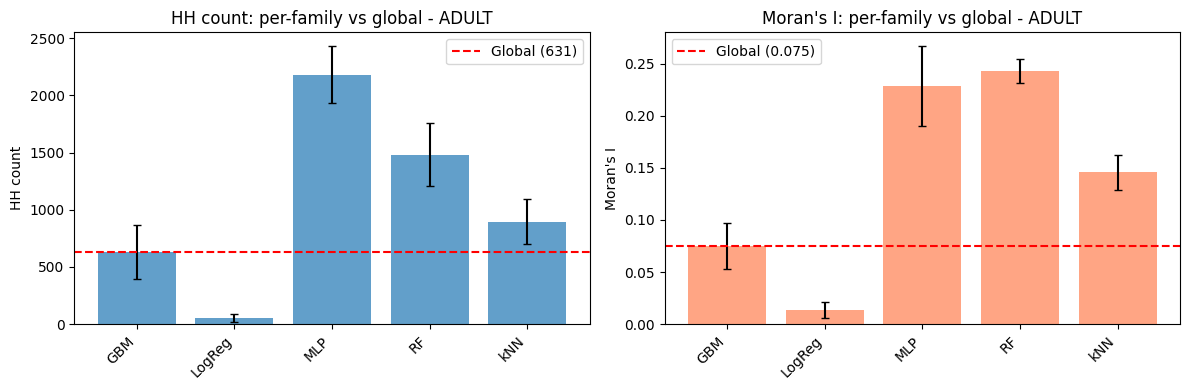

In [117]:
from pathlib import Path

DATASETS_FIG4 = ["compas", "german", "adult"]

for dataset in DATASETS_FIG4:
    per_family_path = RAW_RESULTS / dataset / "per_family_spatial_aggregated.csv"
    summary_path = RAW_RESULTS / dataset / "summary_per_run.csv"

    print(f"Using per-family CSV: {per_family_path}")
    print(f"Using global summary CSV: {summary_path}")

    if not per_family_path.exists():
        raise FileNotFoundError(f"Missing per-family CSV: {per_family_path}")
    if not summary_path.exists():
        raise FileNotFoundError(f"Missing summary CSV: {summary_path}")

    fam_agg = pd.read_csv(per_family_path)
    summary_df = pd.read_csv(summary_path)

    if "family" not in fam_agg.columns:
        raise ValueError("per_family_spatial_aggregated.csv must contain a 'family' column")

    glob_mean_hh = summary_df["n_hh"].mean()
    glob_mean_moran = summary_df["moran_i"].mean()

    print(f"{dataset}: Global mean HH = {glob_mean_hh:.1f}, Global mean Moran's I = {glob_mean_moran:.4f}")
    print()

    fam_agg = fam_agg.sort_values("family")
    families = fam_agg["family"].values
    x = range(len(families))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.bar(x, fam_agg["n_hh_mean"], yerr=fam_agg["n_hh_std"], capsize=3, alpha=0.7)
    ax1.axhline(glob_mean_hh, color="red", ls="--", label=f"Global ({glob_mean_hh:.0f})")
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(families, rotation=45, ha="right")
    ax1.set_ylabel("HH count")
    ax1.set_title(f"HH count: per-family vs global - {dataset.upper()}")
    ax1.legend()

    ax2.bar(x, fam_agg["moran_i_mean"], yerr=fam_agg["moran_i_std"], capsize=3, alpha=0.7, color="coral")
    ax2.axhline(glob_mean_moran, color="red", ls="--", label=f"Global ({glob_mean_moran:.3f})")
    ax2.set_xticks(list(x))
    ax2.set_xticklabels(families, rotation=45, ha="right")
    ax2.set_ylabel("Moran's I")
    ax2.set_title(f"Moran's I: per-family vs global - {dataset.upper()}")
    ax2.legend()

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"family_vs_global_spatial_{dataset}.pdf", bbox_inches="tight")
    plt.show()


## Variance vs Conflict hotspots

Side-by-side PCA plots comparing variance-based HH and conflict-based HH for the representative run. Also shows overlap vs XOR (symmetric difference) and reports Jaccard overlap.

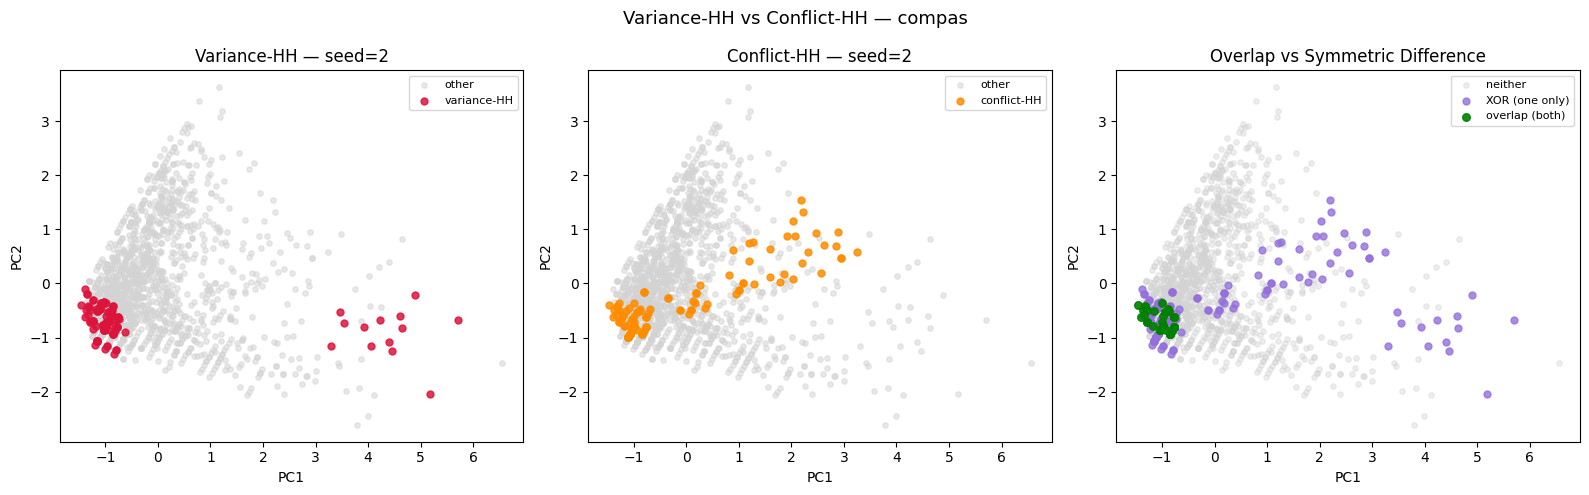

Variance-HH vs Conflict-HH Jaccard for seed=2:
  |var-HH| = 117, |conf-HH| = 124
  |intersection| = 41, |union| = 200
  Jaccard = 0.2050


In [118]:
# Conflict-HH vs variance-HH for the representative run
r_rep = spatial_by_run[rep_idx]
var_hh = r_rep["HH_mask"]
conf_hh = r_rep.get("conflict_HH_mask", np.zeros(len(var_hh), dtype=bool))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: variance-HH
axes[0].scatter(coords[~var_hh, 0], coords[~var_hh, 1], c="lightgray", s=15, alpha=0.5, label="other")
axes[0].scatter(coords[var_hh, 0], coords[var_hh, 1], c="crimson", s=25, alpha=0.85, label="variance-HH")
axes[0].set_title(f"Variance-HH — {r_rep['run_dir']}")
axes[0].set_xlabel("PC1" if n_features > 2 else "Feature 1")
axes[0].set_ylabel("PC2" if n_features > 2 else "Feature 2")
axes[0].legend(fontsize=8)

# Panel B: conflict-HH
axes[1].scatter(coords[~conf_hh, 0], coords[~conf_hh, 1], c="lightgray", s=15, alpha=0.5, label="other")
axes[1].scatter(coords[conf_hh, 0], coords[conf_hh, 1], c="darkorange", s=25, alpha=0.85, label="conflict-HH")
axes[1].set_title(f"Conflict-HH — {r_rep['run_dir']}")
axes[1].set_xlabel("PC1" if n_features > 2 else "Feature 1")
axes[1].set_ylabel("PC2" if n_features > 2 else "Feature 2")
axes[1].legend(fontsize=8)

# Panel C: overlap vs XOR
overlap = var_hh & conf_hh
xor = var_hh ^ conf_hh
rest = ~(var_hh | conf_hh)
axes[2].scatter(coords[rest, 0], coords[rest, 1], c="lightgray", s=15, alpha=0.4, label="neither")
axes[2].scatter(coords[xor, 0], coords[xor, 1], c="mediumpurple", s=25, alpha=0.8, label="XOR (one only)")
axes[2].scatter(coords[overlap, 0], coords[overlap, 1], c="green", s=30, alpha=0.9, label="overlap (both)")
axes[2].set_title("Overlap vs Symmetric Difference")
axes[2].set_xlabel("PC1" if n_features > 2 else "Feature 1")
axes[2].set_ylabel("PC2" if n_features > 2 else "Feature 2")
axes[2].legend(fontsize=8)

fig.suptitle(f"Variance-HH vs Conflict-HH — {DATASET}", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / f"var_vs_conflict_hh_{DATASET}.pdf", bbox_inches="tight")
plt.show()

# Jaccard overlap
union_count = int(np.sum(var_hh | conf_hh))
inter_count = int(np.sum(var_hh & conf_hh))
J_vc = inter_count / union_count if union_count > 0 else 0.0
print(f"Variance-HH vs Conflict-HH Jaccard for {r_rep['run_dir']}:")
print(f"  |var-HH| = {int(np.sum(var_hh))}, |conf-HH| = {int(np.sum(conf_hh))}")
print(f"  |intersection| = {inter_count}, |union| = {union_count}")
print(f"  Jaccard = {J_vc:.4f}")

## HH overlap stability

Pairwise Jaccard overlaps between HH masks across all seed pairs for both variance-HH and conflict-HH. Also cross Jaccard (variance-HH vs conflict-HH) per seed.

C:\Users\dejvi\AppData\Local\Temp\ipykernel_6248\2167941155.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot([off_diag_var, off_diag_conf], labels=["Variance-HH", "Conflict-HH"],


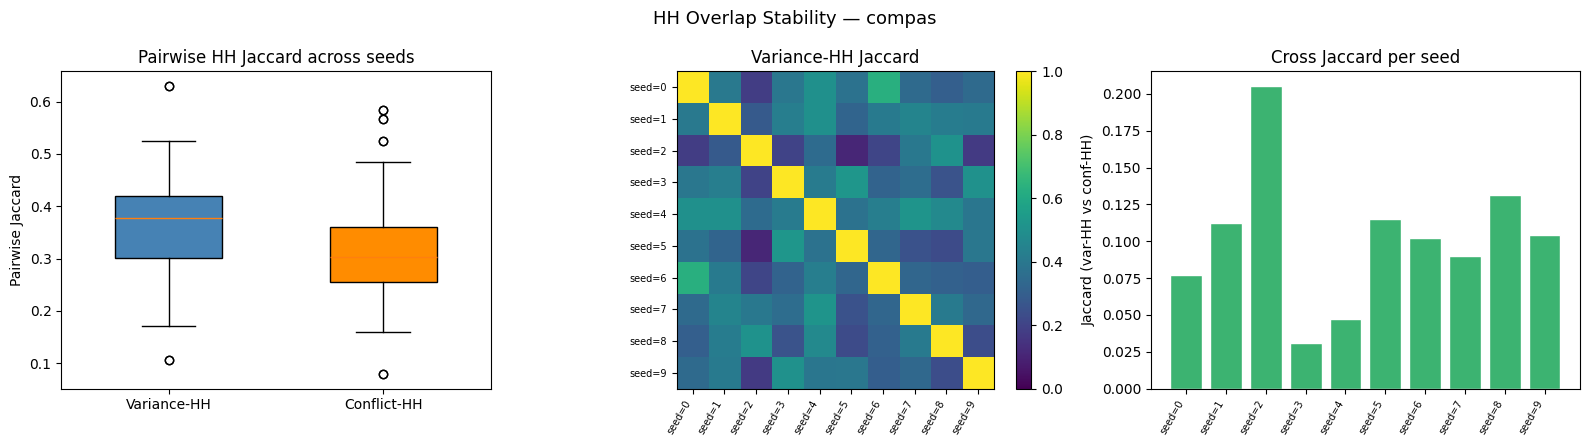

Variance-HH pairwise Jaccard: mean=0.363, std=0.107
Conflict-HH pairwise Jaccard: mean=0.319, std=0.107
Cross Jaccard (var vs conf) per seed: mean=0.101, std=0.045


In [119]:
from analysis.stability import hh_jaccard_matrix

# Variance-HH pairwise Jaccard (already computed as J in cell 6)
var_hh_masks = [r["HH_mask"] for r in spatial_by_run]
J_var = hh_jaccard_matrix(var_hh_masks)

# Conflict-HH pairwise Jaccard
conf_hh_masks = [r.get("conflict_HH_mask", np.zeros(len(r["HH_mask"]), dtype=bool)) for r in spatial_by_run]
J_conf = hh_jaccard_matrix(conf_hh_masks)

# Cross: variance-HH vs conflict-HH per seed
cross_jaccards = []
for r in spatial_by_run:
    v = r["HH_mask"]
    c = r.get("conflict_HH_mask", np.zeros(len(v), dtype=bool))
    union_c = int(np.sum(v | c))
    j = int(np.sum(v & c)) / union_c if union_c > 0 else 0.0
    cross_jaccards.append(j)

n_seeds = len(spatial_by_run)
run_labels = [r["run_dir"] for r in spatial_by_run]

# Extract off-diagonal values
off_diag_var = J_var[~np.eye(n_seeds, dtype=bool)]
off_diag_conf = J_conf[~np.eye(n_seeds, dtype=bool)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# A) Boxplot of pairwise Jaccard (variance-HH and conflict-HH)
bp = axes[0].boxplot([off_diag_var, off_diag_conf], labels=["Variance-HH", "Conflict-HH"],
                     patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][1].set_facecolor("darkorange")
axes[0].set_ylabel("Pairwise Jaccard")
axes[0].set_title("Pairwise HH Jaccard across seeds")

# B) Jaccard heatmap for variance-HH
im1 = axes[1].imshow(J_var, cmap="viridis", vmin=0, vmax=1)
axes[1].set_xticks(range(n_seeds)); axes[1].set_xticklabels(run_labels, rotation=60, ha="right", fontsize=7)
axes[1].set_yticks(range(n_seeds)); axes[1].set_yticklabels(run_labels, fontsize=7)
axes[1].set_title("Variance-HH Jaccard")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# C) Cross Jaccard per seed
axes[2].bar(range(n_seeds), cross_jaccards, color="mediumseagreen", edgecolor="white")
axes[2].set_xticks(range(n_seeds))
axes[2].set_xticklabels(run_labels, rotation=60, ha="right", fontsize=7)
axes[2].set_ylabel("Jaccard (var-HH vs conf-HH)")
axes[2].set_title("Cross Jaccard per seed")

fig.suptitle(f"HH Overlap Stability — {DATASET}", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / f"hh_jaccard_distributions_{DATASET}.pdf", bbox_inches="tight")
plt.show()

print(f"Variance-HH pairwise Jaccard: mean={off_diag_var.mean():.3f}, std={off_diag_var.std():.3f}")
print(f"Conflict-HH pairwise Jaccard: mean={off_diag_conf.mean():.3f}, std={off_diag_conf.std():.3f}")
print(f"Cross Jaccard (var vs conf) per seed: mean={np.mean(cross_jaccards):.3f}, std={np.std(cross_jaccards):.3f}")

## Region-level stability metrics

Pointwise Jaccard is low, but that doesn't mean the *regions* are unstable. We compute three complementary region-level metrics:
1. **HH frequency mass** â€” proportion of total HH-frequency concentrated in the top component(s)
2. **Component centroid stability** â€” distance between centroids of the largest HH component across seeds (in PCA space)
3. **Smoothed overlap** â€” Jaccard after 1-hop neighborhood dilation (treats HH as regions, not exact points)

In [120]:
from sklearn.decomposition import PCA
from analysis.knn_defaults import K_NN_BY_DATASET
from analysis.spatial import extract_hh_components
DATASETS = ['compas', 'german', 'adult']

# Defaults if this cell runs before the cell that sets RESULTS_DIR, K
if 'RESULTS_DIR' not in dir() or not isinstance(RESULTS_DIR if 'RESULTS_DIR' in dir() else None, Path):
    try:
        from thesis_layout import RAW_RESULTS as _RR
        RESULTS_DIR = _RR
    except Exception:
        RESULTS_DIR = Path("results")
if 'K' not in dir():
    K = 25

# Build all_runs if not already defined (avoids NameError when cell run alone)
all_runs = globals().get("all_runs", None)
if all_runs is None:
    all_runs = []
    for _ds in DATASETS:
        dataset_dir = RESULTS_DIR / _ds
        run_dirs_ds = _get_run_dirs(dataset_dir)
        if not run_dirs_ds:
            continue
        for run_dir in run_dirs_ds:
            n_cand = len(load_meta(run_dir))
            K_actual = min(K, n_cand)
            X_test = get_transformed_test_features(run_dir, _ds)
            res = run_spatial(run_dir, X_test, K=K_actual, k=K_NN_BY_DATASET[_ds], seed=42)
            r = dict(res)
            r["dataset"] = _ds
            r["X_test"] = X_test
            all_runs.append(r)

for ds in DATASETS:
    print(f"\n{'='*60}")
    print(f"  Region-level stability: {ds}")
    print(f"{'='*60}")

    ds_runs = [r for r in all_runs if r["dataset"] == ds]
    if not ds_runs:
        print("  (no runs)")
        continue

    hh_masks_ds = [r["HH_mask"] for r in ds_runs]
    freq = hh_selection_frequency(hh_masks_ds)

    X_test_first = ds_runs[0]["X_test"]
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_test_first)

    components_list = []
    for r in ds_runs:
        lisa_df = pd.DataFrame({"cluster": np.where(r["HH_mask"], "HH", "NS")})
        W_sparse = r["W"].to_sparse() if hasattr(r["W"], "to_sparse") else r["W"].sparse
        _, comps = extract_hh_components(lisa_df, W_sparse, min_size=5)
        components_list.append(comps)

    W_sparse = ds_runs[0]["W"].to_sparse() if hasattr(ds_runs[0]["W"], "to_sparse") else ds_runs[0]["W"].sparse
    summary = summarize_hh_stability(hh_masks_ds)

    print(f"\n  Point-level stability:")
    print(f"    Mean Jaccard (pointwise):        {summary['mean_jaccard']:.4f}")
    print(f"    Min Jaccard:                     {summary['min_jaccard']:.4f}")
    print(f"    Max Jaccard:                     {summary['max_jaccard']:.4f}")
    print(f"    HH support |{{i : f_i > 0}}|/N:   {summary['hh_support_size']:.4f}")
    print(
        f"    On support: mean f_i = {summary['hh_support_mean_f']:.4f}, "
        f"median = {summary['hh_support_median_f']:.4f}"
    )
    print(
        "    Support buckets (counts):",
        int(summary["hh_support_bucket_00_02"]),
        int(summary["hh_support_bucket_02_05"]),
        int(summary["hh_support_bucket_05_08"]),
        int(summary["hh_support_bucket_08_10"]),
    )
    print(
        "    Support buckets (frac of support):",
        f"{summary['hh_support_bucket_00_02_frac']:.3f},",
        f"{summary['hh_support_bucket_02_05_frac']:.3f},",
        f"{summary['hh_support_bucket_05_08_frac']:.3f},",
        f"{summary['hh_support_bucket_08_10_frac']:.3f}",
    )
    print(
        f"    Core-to-support (f_i>=0.5)/support: "
        f"{summary['hh_core_to_support_ratio']:.4f}"
    )


  Region-level stability: compas

  Point-level stability:
    Mean Jaccard (pointwise):        0.3631
    Min Jaccard:                     0.1069
    Max Jaccard:                     0.6303
    HH support |{i : f_i > 0}|/N:   0.2155
    On support: mean f_i = 0.3611, median = 0.2000
    Support buckets (counts): 175 55 49 32
    Support buckets (frac of support): 0.563, 0.177, 0.158, 0.103
    Core-to-support (f_i>=0.5)/support: 0.2830

  Region-level stability: german

  Point-level stability:
    Mean Jaccard (pointwise):        0.1557
    Min Jaccard:                     0.0000
    Max Jaccard:                     1.0000
    HH support |{i : f_i > 0}|/N:   0.1050
    On support: mean f_i = 0.1667, median = 0.1000
    Support buckets (counts): 17 3 1 0
    Support buckets (frac of support): 0.810, 0.143, 0.048, 0.000
    Core-to-support (f_i>=0.5)/support: 0.0476

  Region-level stability: adult

  Point-level stability:
    Mean Jaccard (pointwise):        0.4228
    Min Jaccard: 

## Regionality metrics of HH hotspots

To summarize the structure of multiplicity regions, we compute regionality metrics based on connected components of HH hotspots.

These metrics describe whether hotspots form a few large coherent regions or many small fragmented clusters.

component_sizes: [41, 15, 9]


,n_hh_points,n_components,largest_component_size,mean_component_size,median_component_size,share_in_largest_component,fragmentation_index
0,68,3,41,21.666667,15.0,0.602941,0.044118


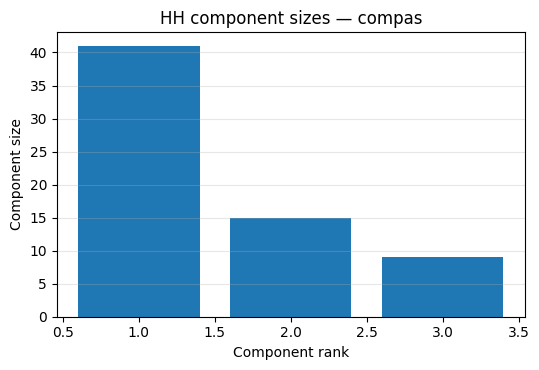

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# components is expected to be a dict: component_id -> array of member indices
# HH_mask is the boolean mask of HH hotspot points for the representative run

if not isinstance(components, dict):
    raise TypeError(f"`components` should be a dict, got {type(components)}")

component_sizes = (
    np.array([len(v) for v in components.values()], dtype=int)
    if len(components) > 0
    else np.array([], dtype=int)
)

n_hh_points = int(HH_mask.sum())

regionality_df = pd.DataFrame([{
    "n_hh_points": n_hh_points,
    "n_components": int(len(component_sizes)),
    "largest_component_size": int(component_sizes.max()) if len(component_sizes) else 0,
    "mean_component_size": float(component_sizes.mean()) if len(component_sizes) else 0.0,
    "median_component_size": float(np.median(component_sizes)) if len(component_sizes) else 0.0,
    "share_in_largest_component": (
        float(component_sizes.max() / n_hh_points)
        if n_hh_points > 0 and len(component_sizes)
        else 0.0
    ),
    "fragmentation_index": (
        float(len(component_sizes) / n_hh_points)
        if n_hh_points > 0
        else 0.0
    ),
}])

print("component_sizes:", component_sizes.tolist())
display(regionality_df)

# optional bar plot of component sizes
if len(component_sizes) > 0:
    sizes_sorted = np.sort(component_sizes)[::-1]

    plt.figure(figsize=(5.5, 3.8))
    plt.bar(range(1, len(sizes_sorted) + 1), sizes_sorted)
    plt.xlabel("Component rank")
    plt.ylabel("Component size")
    plt.title(f"HH component sizes — {DATASET}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No HH components found.")